## 1. Descripción a alto nivel
Se constuye un agente en el que un LLM procesa el prompt de usuario, desgranando las tareas que se piden, llamando a herramientas para completarlas y finalmente, cuando considera que dispone de toda la información, componer una respuesta para el usuario. Se trata de una arquitectura ReAct (Reasoning and Acting: https://www.ibm.com/think/topics/react-agent)

Es un agente con memoria para cada usuario, que puede escoger si seguir con una conversación previa o inicar una nueva. En el notebook cada usuario se identifica con un thread_id
En este momento el agente dispone de dos herramientas:
- el modelo que infiere los mejores lugares para ubicar un negocio de hostelería dadas una serie de características (zona, perfil de cliente, características del servicio ofrecido, etc). Ofrece un iterfaz tipo API al modelo. Dado que es solamente una aplicación ad-hoc, no se considera el uso de MCP
- un RAG que da contexto sobre cuestiones de normativa y procedimientos 

Se usa el framework LangChain/LangGraph en tanto que provee unos esquemas estándar que se consideran particularmente útiles a la hora de introducirse en este mundo, empezar por genérico para poder evolucionar a lo particualar de un proveedor o tecnología, de ser necesario

La principal característica del modelo que soporta el agente que decide si se debe usar una tool y cuál y en qué punto dispone de toda la información para poder finalizar, es la de 'razonamiento'.
No se ha hecho porqué con el usuario genérico del PJ (geoyield@gmail.com)m no es posible crear cuenta en Google AI Studio. Es por ello que se usa usa groq: https://pricepertoken.com/endpoints/groq/free

El agente se plantea con memoria durante la interacción, de forma que las respuestas previas se añaden al contexto. Cada conversación dispone de un identificador, por lo que se puede retomar más tarde. Para evitar un crecimiento desmesurado del contexto, los mensajes más antiguos se se se van añadiendo a un mensaje de resumen en la base de la lista. 

Una vez comporbado el funcionamiento, se va a persistir en potgis la conversaciones de los usuarios (https://docs.langchain.com/oss/python/langgraph/add-memory#example-using-postgres-checkpointer)


In [ ]:
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from pydantic import BaseModel
import requests
import json

from dotenv import load_dotenv

from sqlalchemy import create_engine
from sqlalchemy.orm import Session

import sys
from pathlib import Path
project_root = next((parent for parent in Path.cwd().resolve().parents
                        if Path(parent, 'backend').is_dir()))
sys.path.insert(0, str(project_root))

from backend.db.connection import resolve_database_url
from backend.rag.query_engine import retrieve_relevant_chunks, build_context
from backend.rag.embeddings import embed_texts
         
from sqlalchemy import create_engine
from sqlalchemy.orm import Session

In [41]:
load_dotenv()

os.environ.setdefault("DB_HOST_OVERRIDE", "localhost")
os.environ.setdefault("HF_HUB_OFFLINE", "1")  # El modelo ya está cacheado, no hace falta red para esto

GENERATION_MODEL = 'models/gemini-3.6-flash'
GEODATA_BASEURL = resolve_database_url()

engine = create_engine(resolve_database_url())

In [11]:
class geodata(BaseModel):
    latitude: float
    longitude: float
    address: str
    business_type: str

class geodata_query(BaseModel):
    query: geodata

class geodata_result(BaseModel):
    score: float
    result: geodata

class geodata_output(BaseModel):
    results: list[geodata_result]


def geo_query(query: geodata_query) -> geodata_output:
    """
    proporciona información sobre las mejores ubicaciones para un negocio de hostelería de unas dadas características en la ciudad de Barcelona, 
    obtiene la informaci´pon en base a requests a los endpoints de GEODATA_URL

    Args:
        query (geodata_query): Objeto que contiene la información de la ubicación a consultar.
    """
    response = requests.post(f'{GEODATA_BASEURL}/endpoint/', json=query)
    if response.status_code == 200:
        return geodata_output(**response.json())
    else:
        raise Exception(f"Error in geodata_query: {response.status_code} - {response.text}")

In [44]:

def regulations_query(query: str) -> str:
    """
    proporciona información sobre aspectos regulatorios y legales.

    Args:
        query (str): Consulta en lenguaje natural.

    """
    documents = []  
    
    with Session(engine) as session:
        documents = retrieve_relevant_chunks(session=session,
                                             query=query,
                                             embed_fn=embed_texts,
                                             top_k=3,
                                            )
    return build_context(documents)

In [45]:
tools = [geo_query, regulations_query ]
llm = ChatGoogleGenerativeAI(
    model=GENERATION_MODEL,
    temperature=0,
    max_retries=3,
 )
llm_with_tools = llm.bind_tools(tools)

In [46]:
sys_msg = SystemMessage(
    content="""Eres un asistente experto en hostelería y restauración, especializado en la ciudad de Barcelona. 
    Tu tarea es ayudar a los usuarios a encontrar las mejores ubicaciones para abrir un negocio de hostelería, 
    así como proporcionar información sobre aspectos regulatorios y legales relacionados con la apertura de negocios en esta ciudad. 
    Dispones de dos herramientas para ayudarte en tu tarea:
    1. geo_query: Esta herramienta te permite obtener información sobre las mejores ubicaciones para un negocio de hostelería en Barcelona.
    2. regulations_query: Esta herramienta te permite obtener información sobre aspectos regulatorios y legales relacionados con la apertura de negocios en Barcelona.
    Cuando respondas a las consultas de los usuarios, asegúrate de proporcionar información precisa y relevante, y de citar las fuentes de información cuando sea posible.
    Si no puedes encontrar información relevante, informa al usuario de que no se encontró información relevante.""")

def assistant(state: MessagesState):
    """
    Función principal del asistente, que recibe un estado de mensajes y devuelve una respuesta generada por el modelo de lenguaje.

    Args:
        state (MessagesState): Estado de mensajes que contiene la conversación actual.
    """
    return {'messages': [llm_with_tools.invoke([sys_msg] + state['messages'])]}


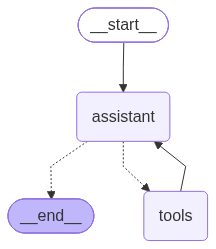

In [47]:
from langgraph.graph import StateGraph, START
from langgraph.prebuilt  import tools_condition, ToolNode
from langgraph.checkpoint.memory import MemorySaver  
from IPython.display import Image, display 

# Memory
memory = MemorySaver()

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile(checkpointer=memory)

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [51]:
messages = [{
    'role': 'user',
    'content': 'cual es la normativa aplicable en Barcelona para poner una terraza de bar en vía pública'
}]
configurable = {'thread_id': '1'}

state = react_graph.invoke(
    {'messages': messages},
    {'configurable': configurable}
 )

for message in state['messages']:
    message.pretty_print()

# Para recuperar posteriormente el último estado guardado del mismo hilo:
# state = react_graph.get_state({'configurable': configurable}).values

/home/claud/pontia/PJ/.venv-1/lib/python3.12/site-packages/langchain_google_genai/chat_models.py:3237: UserWarning: Model 'models/gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/home/claud/pontia/PJ/.venv-1/lib/python3.12/site-packages/langchain_google_genai/chat_models.py:3237: UserWarning: Model 'models/gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


================================ Human Message =================================

cual es la normativa aplicable en Barcelona para poner una terraza de bar en vía públilca
================================== Ai Message ==================================

[]
Tool Calls:
  regulations_query (call_5378299)
 Call ID: call_5378299
  Args:
    query: normativa para poner una terraza de bar en la vía pública en Barcelona
================================ Human Message =================================

cual es la normativa aplicable en Barcelona para poner una terraza de bar en vía públilca
================================== Ai Message ==================================

[]
Tool Calls:
  regulations_query (call_4537099)
 Call ID: call_4537099
  Args:
    query: Ordenanza de terrazas Barcelona requisitos licencia via publica
================================= Tool Message =================================
Name: regulations_query


================================== Ai Message ====================

In [71]:
state['messages'][-1].model_dump()

{'content': [{'type': 'text',
   'text': 'Como se ha mencionado anteriormente, la normativa principal que regula la instalación de terrazas en la vía pública en Barcelona es la **Ordenanza de Terrazas del Ayuntamiento de Barcelona** (*Ordinança de Terrasses*).\n\nA modo de resumen, los puntos regulatorios clave son los siguientes:\n\n1. **Licencia y Tramitación**:\n   * Es imprescindible contar con la **licencia de actividad del establecimiento** de hostelería en regla.\n   * Se debe solicitar una **autorización de uso de la vía pública** ante el Ayuntamiento (vía telemática) adjuntando el plano a escala con la propuesta de distribución.\n\n2. **Requisitos de Accesibilidad y Espacio**:\n   * **Ancho libre para peatones**: Se exige mantener un itinerario peatonal accesible continuo (por lo general, un mínimo de 1,80 m a 2,50 m según el ancho de la acera).\n   * **Distancias mínimas**: Respetar distancias de seguridad con respecto a fachadas, accesos a portales, pasos de peatones, parada

In [66]:
print(state['messages'][-1].content[0]['text'])

Como se ha mencionado anteriormente, la normativa principal que regula la instalación de terrazas en la vía pública en Barcelona es la **Ordenanza de Terrazas del Ayuntamiento de Barcelona** (*Ordinança de Terrasses*).

A modo de resumen, los puntos regulatorios clave son los siguientes:

1. **Licencia y Tramitación**:
   * Es imprescindible contar con la **licencia de actividad del establecimiento** de hostelería en regla.
   * Se debe solicitar una **autorización de uso de la vía pública** ante el Ayuntamiento (vía telemática) adjuntando el plano a escala con la propuesta de distribución.

2. **Requisitos de Accesibilidad y Espacio**:
   * **Ancho libre para peatones**: Se exige mantener un itinerario peatonal accesible continuo (por lo general, un mínimo de 1,80 m a 2,50 m según el ancho de la acera).
   * **Distancias mínimas**: Respetar distancias de seguridad con respecto a fachadas, accesos a portales, pasos de peatones, paradas de autobús, vados y mobiliario urbano.

3. **Horar